In [1]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

# ! pip install tensorflow
# ! pip install keras
import keras

In [2]:
titanic = pandas.read_csv("https://github.com/dragonnomada/ml-cic-febrero-2026/blob/main/conjuntos/titanic.csv?raw=true")

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: >

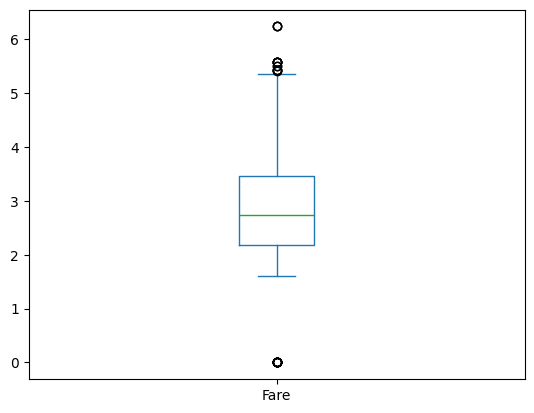

In [20]:
titanic["Fare"].map(numpy.log1p).plot.box()

In [33]:
y = titanic["Survived"] # Respuesta binaria

x1 = 4 - titanic["Pclass"] # 1 - baja | 2 - Medio | 3 - Alto
x2 = (titanic["Sex"] == "female").astype(int)
x3 = titanic["Age"].fillna(titanic["Age"].median())
x4 = titanic["SibSp"] + titanic["Parch"]
x5 = titanic["Fare"].map(numpy.log1p)
x6 = (~titanic["Cabin"].isna()).astype(int)
x7 = titanic["Embarked"] == "Q"
x8 = titanic["Embarked"] == "C"

x4.name = "FamilySize"
x7.name = "EmbarkedQ"
x8.name = "EmbarkedC"

X = pandas.DataFrame([x1, x2, x3, x4, x5, x6, x7, x8]).T # k = 8 | n = 891

X

,Pclass,Sex,Age,FamilySize,Fare,Cabin,EmbarkedQ,EmbarkedC
0,1.0,0.0,22.0,1.0,2.110213,0.0,0.0,0.0
1,3.0,1.0,38.0,1.0,4.280593,1.0,0.0,1.0
2,1.0,1.0,26.0,0.0,2.188856,0.0,0.0,0.0
3,3.0,1.0,35.0,1.0,3.990834,1.0,0.0,0.0
4,1.0,0.0,35.0,0.0,2.202765,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
886,2.0,0.0,27.0,0.0,2.639057,0.0,0.0,0.0
887,3.0,1.0,19.0,0.0,3.433987,1.0,0.0,0.0
888,1.0,1.0,28.0,3.0,3.196630,0.0,0.0,0.0
889,3.0,0.0,26.0,0.0,3.433987,1.0,0.0,1.0


In [37]:
891 * 0.80 # 713

712.8000000000001

In [50]:
indices = X.index.values.copy() # y.index.values.copy()

numpy.random.shuffle(indices)

indices

array([522, 410, 107, 230, 599, 225, 375, 202, 447, 653, 656, 724, 747,
       270, 165, 470, 432, 851, 349, 605, 226, 823, 562, 284,   3, 828,
       644, 659, 567, 180, 548, 389, 278, 681, 455, 101, 219, 408, 326,
       855, 890, 481, 438,  98, 417, 200, 792,  16, 173, 704, 462, 317,
       513,  99, 608, 544, 691, 411, 740, 174,  67, 849, 559, 689, 327,
       320, 869, 877, 186, 498, 238, 298, 433, 184, 182, 799, 431, 596,
       183, 817, 527, 509, 441, 253, 473, 247,  74, 263, 181,  85, 163,
       692, 164, 686, 651, 268, 598,  73, 209, 322, 490, 402, 729, 275,
       421, 753, 796, 220, 467, 500, 632, 232, 244, 756,  51, 793, 619,
       259, 309,  96, 806, 412, 525, 772, 832, 264, 344,  30, 224, 643,
       215, 504, 768, 109, 367, 442,  66, 579,  58, 812, 195, 722, 434,
       463, 245, 846, 550, 781,  20, 571, 715, 682, 765,  52, 266, 227,
       883, 414, 825, 763, 752,  69, 649, 860, 243, 591, 178, 392, 361,
       339,  83, 636,  68, 588, 802, 324, 603, 279, 688, 794, 87

In [51]:
X.iloc[indices[:5]]

,Pclass,Sex,Age,FamilySize,Fare,Cabin,EmbarkedQ,EmbarkedC
522,1.0,0.0,28.0,0.0,2.107178,0.0,0.0,1.0
410,1.0,0.0,28.0,0.0,2.185579,0.0,0.0,0.0
107,1.0,0.0,28.0,0.0,2.171907,0.0,0.0,0.0
230,3.0,1.0,35.0,1.0,4.436456,1.0,0.0,0.0
599,3.0,0.0,49.0,1.0,4.059222,1.0,0.0,1.0


In [52]:
y.iloc[indices[:5]]

522    0
410    0
107    1
230    1
599    1
Name: Survived, dtype: int64

In [53]:
indices[0:713].shape, indices[713:].shape

((713,), (178,))

In [54]:
X_train = X.iloc[indices[:713]]
X_test = X.iloc[indices[713:]]

y_train = y.iloc[indices[:713]]
y_test = y.iloc[indices[713:]]

X_train

,Pclass,Sex,Age,FamilySize,Fare,Cabin,EmbarkedQ,EmbarkedC
522,1.0,0.0,28.0,0.0,2.107178,0.0,0.0,1.0
410,1.0,0.0,28.0,0.0,2.185579,0.0,0.0,0.0
107,1.0,0.0,28.0,0.0,2.171907,0.0,0.0,0.0
230,3.0,1.0,35.0,1.0,4.436456,1.0,0.0,0.0
599,3.0,0.0,49.0,1.0,4.059222,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...
1,3.0,1.0,38.0,1.0,4.280593,1.0,0.0,1.0
477,1.0,0.0,29.0,1.0,2.085150,0.0,0.0,0.0
607,3.0,0.0,27.0,0.0,3.449988,0.0,0.0,0.0
377,3.0,0.0,27.0,2.0,5.358942,1.0,0.0,1.0


In [55]:
y_train

522    0
410    0
107    1
230    1
599    1
      ..
1      1
477    0
607    1
377    0
867    0
Name: Survived, Length: 713, dtype: int64

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=123)

In [64]:
X_train

,Pclass,Sex,Age,FamilySize,Fare,Cabin,EmbarkedQ,EmbarkedC
164,1.0,0.0,1.0,5.0,3.705921,0.0,0.0,0.0
659,3.0,0.0,58.0,2.0,4.738608,1.0,0.0,1.0
536,3.0,0.0,45.0,0.0,3.316003,1.0,0.0,0.0
875,1.0,1.0,15.0,0.0,2.107178,0.0,0.0,1.0
196,1.0,0.0,28.0,0.0,2.169054,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
98,2.0,1.0,34.0,1.0,3.178054,0.0,0.0,0.0
322,2.0,1.0,30.0,0.0,2.591516,0.0,1.0,0.0
382,1.0,0.0,32.0,0.0,2.188856,0.0,0.0,0.0
365,1.0,0.0,30.0,0.0,2.110213,0.0,0.0,0.0


In [62]:
y_train

164    0
659    0
536    0
875    1
196    0
      ..
98     1
322    1
382    0
365    0
510    1
Name: Survived, Length: 791, dtype: int64

<Axes: xlabel='Yp', ylabel='Y'>

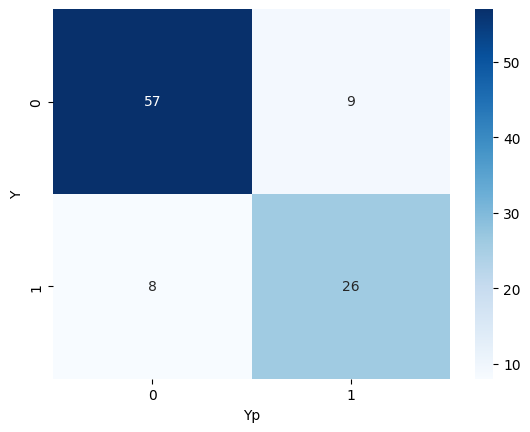

In [84]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=4)

modelo.fit(X_train, y_train)

yp = modelo.predict(X_test)

seaborn.heatmap(
    pandas.DataFrame(
        {
            "Y": y_test,
            "Yp": yp,
        }
    )
    .groupby(["Y", "Yp"])
    .size()
    .unstack(),
    cmap="Blues",
    annot=True
)

In [91]:
(57 + 26) / (57 + 26 + 8 + 9)

0.83

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4340 - loss: 1.7239  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6024 - loss: 0.8223 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5065 - loss: 0.9570 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4641 - loss: 0.9770 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5405 - loss: 0.8443 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5073 - loss: 0.8368 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4894 - loss: 0.8719 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5247 - loss: 0.7575 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5200 - loss: 0.8030 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5664 - loss: 0.7512 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5702 - loss: 0.7315 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

<Axes: xlabel='Yp', ylabel='Y'>

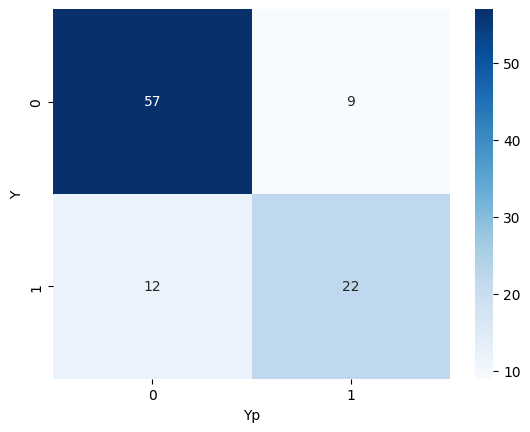

In [90]:
modelo = keras.Sequential([
    keras.Input(shape=(8,)),
    keras.layers.Dense(1, activation="sigmoid")
])

# Compilado
# -> Optimizador (optimizer: sgd | adam | ... | [rmsprop])
# -> Funcion perdida (loss: 1 cat - binary_crossentropy | d cat - categorical_crossentropy | 1 num - mse)
# -> Metricas (cat - accuracy | num - mae)
modelo.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

# Entrenamiento por refuerzo aumentado epocas
# Entrenamiento por lotes (lotes cercanos al 10% de los datos)
modelo.fit(X_train, y_train, epochs=100, batch_size=80)

yp = modelo.predict(X_test)[:, 0] # forma vectorial

seaborn.heatmap(
    (pandas.DataFrame(
        {
            "Y": y_test,
            "Yp": yp,
        }
    ) > 0.5)
    .astype(int)
    .groupby(["Y", "Yp"])
    .size()
    .unstack(),
    cmap="Blues",
    annot=True
)

In [92]:
(57 + 22) / (57 + 22 + 12 + 9)

0.79

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,201 (82.82 KB)

 Trainable params: 21,201 (82.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5250 - loss: 1.0443  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5475 - loss: 0.7033 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5165 - loss: 0.7841
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5687 - loss: 0.6761 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5880 - loss: 0.6703 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6116 - loss: 0.6673 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6313 - loss: 0.6557 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6232 - loss: 0.6470 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6481 - loss: 0.6446 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6269 - loss: 0.6382 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6289 - loss: 0.6393 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6780 - lo

<Axes: xlabel='Yp', ylabel='Y'>

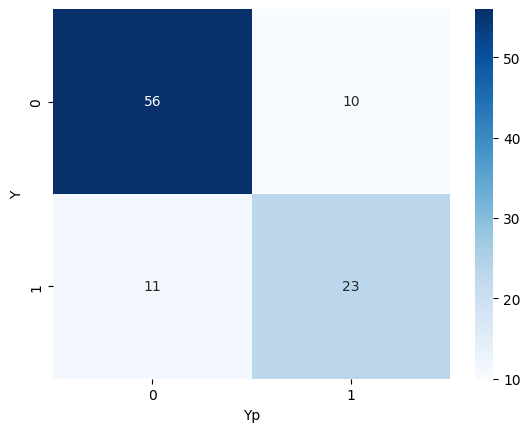

In [96]:
modelo = keras.Sequential([
    keras.Input(shape=(8,)),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

# Compilado
# -> Optimizador (optimizer: sgd | adam | ... | [rmsprop])
# -> Funcion perdida (loss: 1 cat - binary_crossentropy | d cat - categorical_crossentropy | 1 num - mse)
# -> Metricas (cat - accuracy | num - mae)
modelo.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

# Entrenamiento por refuerzo aumentado epocas
# Entrenamiento por lotes (lotes cercanos al 10% de los datos)
modelo.fit(X_train, y_train, epochs=100, batch_size=160)

yp = modelo.predict(X_test)[:, 0] # forma vectorial

seaborn.heatmap(
    (pandas.DataFrame(
        {
            "Y": y_test,
            "Yp": yp,
        }
    ) > 0.5)
    .astype(int)
    .groupby(["Y", "Yp"])
    .size()
    .unstack(),
    cmap="Blues",
    annot=True
)

In [97]:
(56 + 23) / (56 + 23 + 10 + 11)

0.79